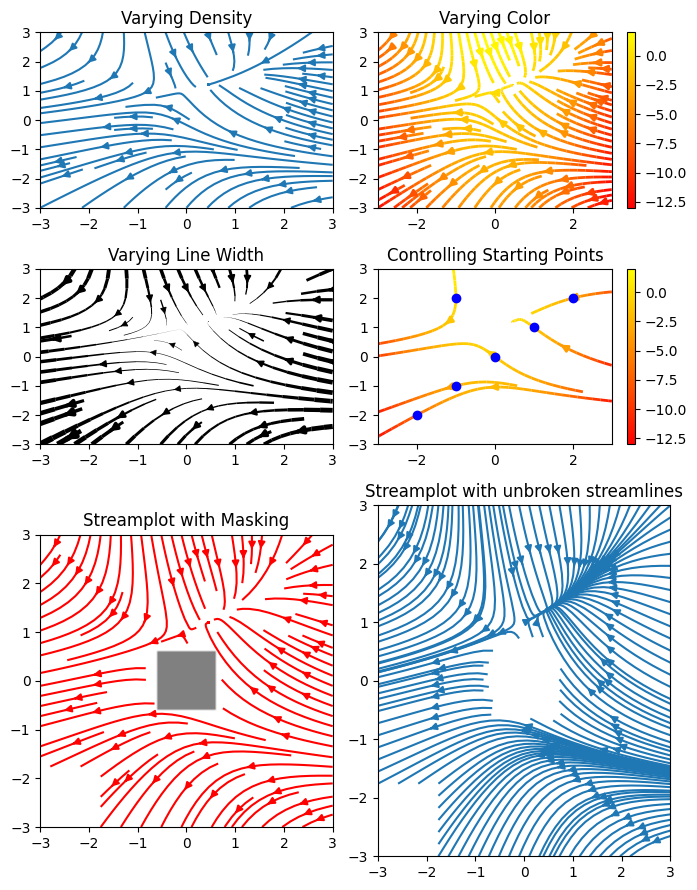

In [1]:
import matplotlib.pyplot as plt
import numpy as np

w = 3
Y, X = np.mgrid[-w:w:100j, -w:w:100j]
U = -1 - X**2 + Y
V = 1 + X - Y**2
speed = np.sqrt(U**2 + V**2)

fig, axs = plt.subplots(3, 2, figsize=(7, 9), height_ratios=[1, 1, 2])
axs = axs.flat

#  Varying density along a streamline
axs[0].streamplot(X, Y, U, V, density=[0.5, 1])
axs[0].set_title('Varying Density')

# Varying color along a streamline
strm = axs[1].streamplot(X, Y, U, V, color=U, linewidth=2, cmap='autumn')
fig.colorbar(strm.lines)
axs[1].set_title('Varying Color')

#  Varying line width along a streamline
lw = 5*speed / speed.max()
axs[2].streamplot(X, Y, U, V, density=0.6, color='k', linewidth=lw)
axs[2].set_title('Varying Line Width')

# Controlling the starting points of the streamlines
seed_points = np.array([[-2, -1, 0, 1, 2, -1], [-2, -1,  0, 1, 2, 2]])

strm = axs[3].streamplot(X, Y, U, V, color=U, linewidth=2,
                         cmap='autumn', start_points=seed_points.T)
fig.colorbar(strm.lines)
axs[3].set_title('Controlling Starting Points')

# Displaying the starting points with blue symbols.
axs[3].plot(seed_points[0], seed_points[1], 'bo')
axs[3].set(xlim=(-w, w), ylim=(-w, w))

# Create a mask
mask = np.zeros(U.shape, dtype=bool)
mask[40:60, 40:60] = True
U[:20, :20] = np.nan
U = np.ma.array(U, mask=mask)

axs[4].streamplot(X, Y, U, V, color='r')
axs[4].set_title('Streamplot with Masking')

axs[4].imshow(~mask, extent=(-w, w, -w, w), alpha=0.5, cmap='gray',
              aspect='auto')
axs[4].set_aspect('equal')

axs[5].streamplot(X, Y, U, V, broken_streamlines=False)
axs[5].set_title('Streamplot with unbroken streamlines')

plt.tight_layout()
plt.show()

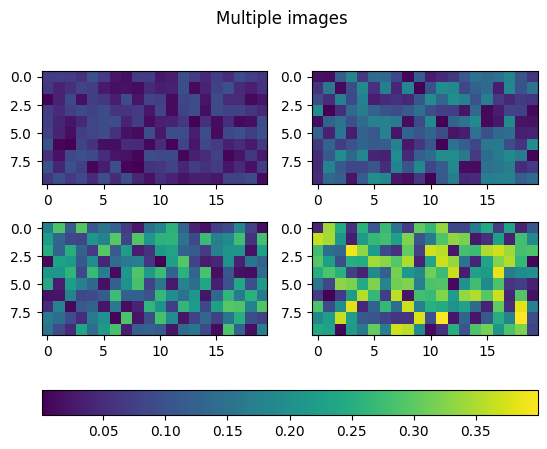

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import colors

np.random.seed(19680801)

datasets = [
    (i+1)/10 * np.random.rand(10, 20)
    for i in range(4)
]

fig, axs = plt.subplots(2, 2)
fig.suptitle('Multiple images')

# create a single norm to be shared across all images
norm = colors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))

images = []
for ax, data in zip(axs.flat, datasets):
    images.append(ax.imshow(data, norm=norm))

fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.1)

plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

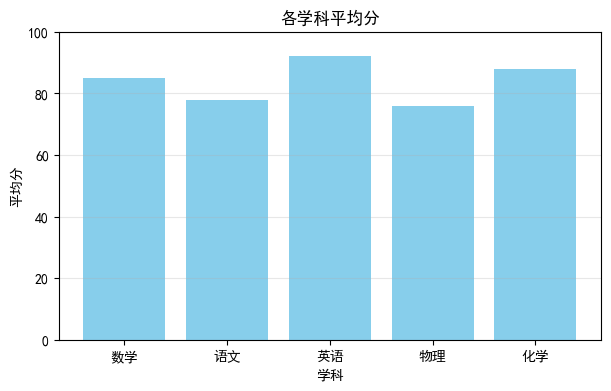

In [9]:
df = pd.read_csv('study_demo.csv')

plt.figure(figsize=(7, 4))
plt.bar(df['学科'], df['平均分'], color='skyblue')

plt.title('各学科平均分')
plt.xlabel('学科')
plt.ylabel('平均分')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()